# Case Study for Bayesian Statistics
## Bayesian Probit Regression & MCMC for Diabetes Prediction

**Authors**: Student 1 (ID) | Student 2 (ID)

**Abstract**: This study employs the Pima Indians Diabetes Dataset to compare and integrate three statistical methodologies for binary classification: Probit regression via Maximum Likelihood Estimation (MLE), Expectation-Maximization (EM) algorithm for latent variable imputation, and full Bayesian Probit regression with Markov Chain Monte Carlo (MCMC) sampling using the Metropolis-Hastings algorithm. The Bayesian framework delivers complete posterior distributions, enabling rigorous uncertainty quantification via Highest Posterior Density (HPD) intervals, posterior predictive checks, and convergence diagnostics. Model comparison reveals that while predictive accuracy is comparable across methods, the Bayesian approach provides richer inference through full posterior characterization and natural incorporation of prior information.

**Keywords**: Bayesian Statistics; Probit Regression; MCMC; Metropolis-Hastings; EM Algorithm; Diabetes Prediction

## 1. Data Description

### Data Source
The dataset originates from the National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK) and comprises diagnostic measurements for female Pima Indians aged at least 21 years. The data were collected for a prospective cohort study investigating risk factors for type 2 diabetes.

### Data Structure
The dataset contains 768 observations across 9 variables:

| Variable | Description | Type |
|----------|-------------|------|
| Pregnancies | Number of pregnancies | Numeric |
| Glucose | 2-hour plasma glucose (mg/dL) | Numeric |
| BloodPressure | Diastolic blood pressure (mm Hg) | Numeric |
| SkinThickness | Triceps skin fold thickness (mm) | Numeric |
| Insulin | 2-hour serum insulin (mu U/mL) | Numeric |
| BMI | Body mass index (kg/m²) | Numeric |
| DiabetesPedigreeFunction | Diabetes pedigree function | Numeric |
| Age | Age (years) | Numeric |
| Outcome | Diabetes status chronically (0 = no, 1 = yes) | Binary |

**Response Variable**: Outcome (binary indicator of diabetes)

**Predictor Variables**: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age

In [11]:
# ============================================================
# Environment Setup & Package Loading
# ============================================================

required_packages <- c("ggplot2", "reshape2", "corrplot", "MASS",
                       "pROC", "coda", "LearnBayes", "TeachingDemos",
                       "viridis", "scales", "gridExtra", "caret",
                       "mvtnorm")

for (pkg in required_packages) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg, repos = "https://cran.r-project.org")
  }
  library(pkg, character.only = TRUE)
}

# Academic color palette
acad_blue   <- "#2C3E50"
acad_red    <- "#C0392B"
acad_green  <- "#27AE60"
acad_orange <- "#E67E22"
acad_purple <- "#8E44AD"
acad_teal   <- "#1ABC9C"
acad_grey   <- "#7F8C8D"
acad_yellow <- "#F39C12"

set.seed(2024)
cat("Packages loaded successfully.\n")
cat("Working directory:", getwd(), "\n")

Packages loaded successfully.
Working directory: d:/AAA-Bayesian/zwy/bayesian_group_project 


In [12]:
# ============================================================
# Data Loading & Initial Inspection
# ============================================================

diabetes <- read.csv("diabetes.csv", header = TRUE)

cat("Dataset dimensions:", nrow(diabetes), "rows x", ncol(diabetes), "columns\n")
cat("\nColumn names:\n")
print(colnames(diabetes))
cat("\nFirst 10 rows:\n")
print(head(diabetes, 10))

cat("\n=== Structure ===\n")
str(diabetes)

cat("\n=== Missing Values ===\n")
print(colSums(is.na(diabetes)))

cat("\n=== Summary Statistics ===\n")
print(summary(diabetes))

Dataset dimensions: 768 rows x 9 columns

Column names:
[1] "Pregnancies"              "Glucose"                 
[3] "BloodPressure"            "SkinThickness"           
[5] "Insulin"                  "BMI"                     
[7] "DiabetesPedigreeFunction" "Age"                     
[9] "Outcome"                 

First 10 rows:
   Pregnancies Glucose BloodPressure SkinThickness Insulin  BMI
1            6     148            72            35       0 33.6
2            1      85            66            29       0 26.6
3            8     183            64             0       0 23.3
4            1      89            66            23      94 28.1
5            0     137            40            35     168 43.1
6            5     116            74             0       0 25.6
7            3      78            50            32      88 31.0
8           10     115             0             0       0 35.3
9            2     197            70            45     543 30.5
10           8     125   

Class Distribution:
  Non-diabetic (0): 500 (65.1%)
  Diabetic (1):     268 (34.9%)


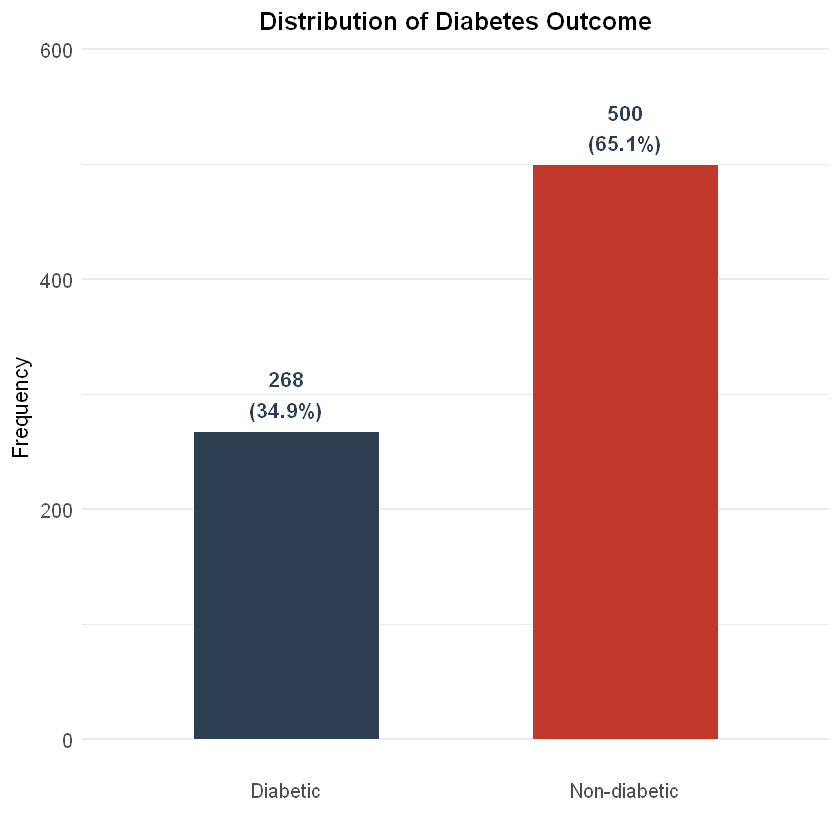

In [13]:
# ============================================================
# Class Distribution Visualization
# ============================================================

tab_outcome <- table(diabetes$Outcome)
prop_outcome <- prop.table(tab_outcome) * 100

cat("Class Distribution:\n")
cat(sprintf("  Non-diabetic (0): %d (%.1f%%)\n", tab_outcome[1], prop_outcome[1]))
cat(sprintf("  Diabetic (1):     %d (%.1f%%)\n", tab_outcome[2], prop_outcome[2]))

df_class <- data.frame(
  Outcome = c("Non-diabetic", "Diabetic"),
  Count   = as.numeric(tab_outcome),
  Percent = as.numeric(prop_outcome)
)

p_class <- ggplot(df_class, aes(x = Outcome, y = Count, fill = Outcome)) +
  geom_bar(stat = "identity", width = 0.55, color = "white", size = 0.3) +
  geom_text(aes(label = paste0(Count, "\n(", round(Percent, 1), "%)")),
            vjust = -0.3, size = 4.5, fontface = "bold", color = acad_blue) +
  scale_fill_manual(values = c(acad_blue, acad_red)) +
  labs(title = "Distribution of Diabetes Outcome",
       x = "", y = "Frequency") +
  ylim(0, max(tab_outcome) * 1.15) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold", hjust = 0.5, size = 15),
        axis.text = element_text(size = 12),
        panel.grid.major.x = element_blank())
print(p_class)

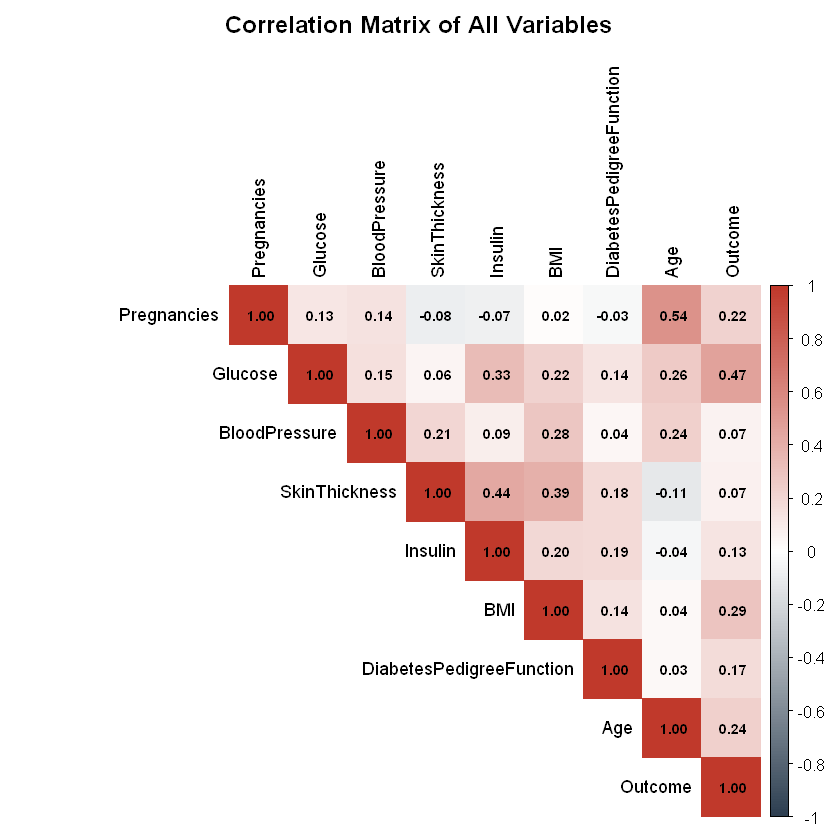

In [14]:
# ============================================================
# Correlation Heatmap
# ============================================================

cor_mat <- cor(diabetes)

corrplot(cor_mat, method = "color", type = "upper",
         col = colorRampPalette(c(acad_blue, "white", acad_red))(200),
         addCoef.col = "black", number.cex = 0.7,
         tl.col = "black", tl.cex = 0.9,
         title = "Correlation Matrix of All Variables",
         mar = c(0, 0, 2, 0))

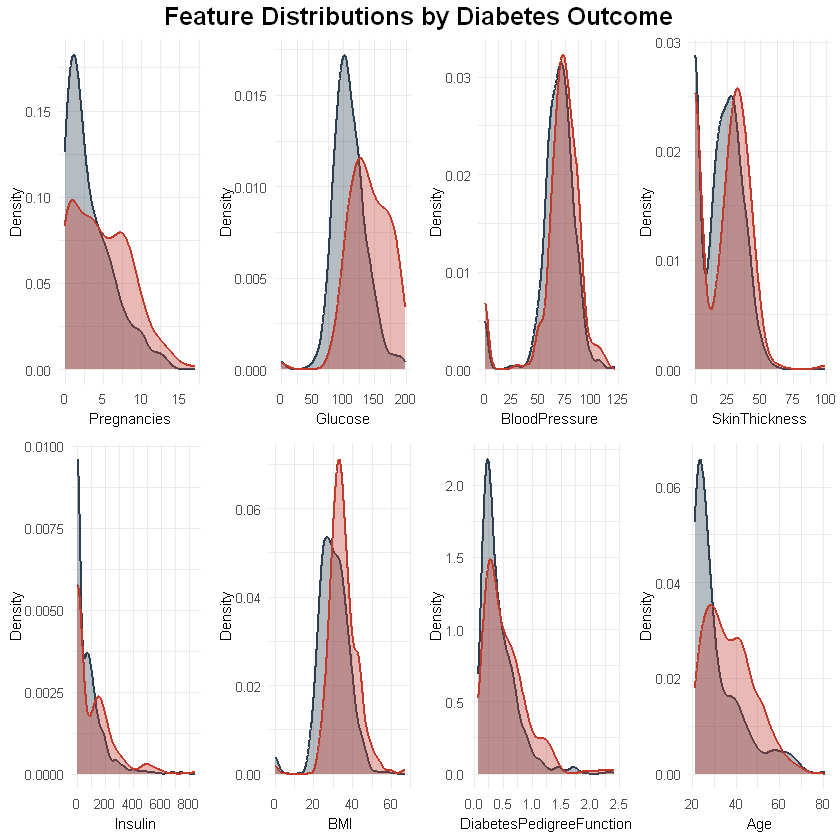

In [15]:
# ============================================================
# Feature Distributions by Outcome (Density Plots)
# ============================================================

features <- setdiff(colnames(diabetes), "Outcome")
diabetes$Outcome_f <- factor(diabetes$Outcome, levels = c(0, 1),
                              labels = c("Non-diabetic", "Diabetic"))

plot_list <- list()
for (f in features) {
  p <- ggplot(diabetes, aes_string(x = f, fill = "Outcome_f", color = "Outcome_f")) +
    geom_density(alpha = 0.35, size = 0.7) +
    scale_fill_manual(values = c(acad_blue, acad_red)) +
    scale_color_manual(values = c(acad_blue, acad_red)) +
    labs(x = f, y = "Density") +
    theme_minimal(base_size = 10) +
    theme(legend.position = "none",
          axis.title = element_text(size = 9))
  plot_list[[f]] <- p
}

grid.arrange(grobs = plot_list, ncol = 4,
             top = grid::textGrob("Feature Distributions by Diabetes Outcome",
                                  gp = grid::gpar(fontface = "bold", fontsize = 15)))

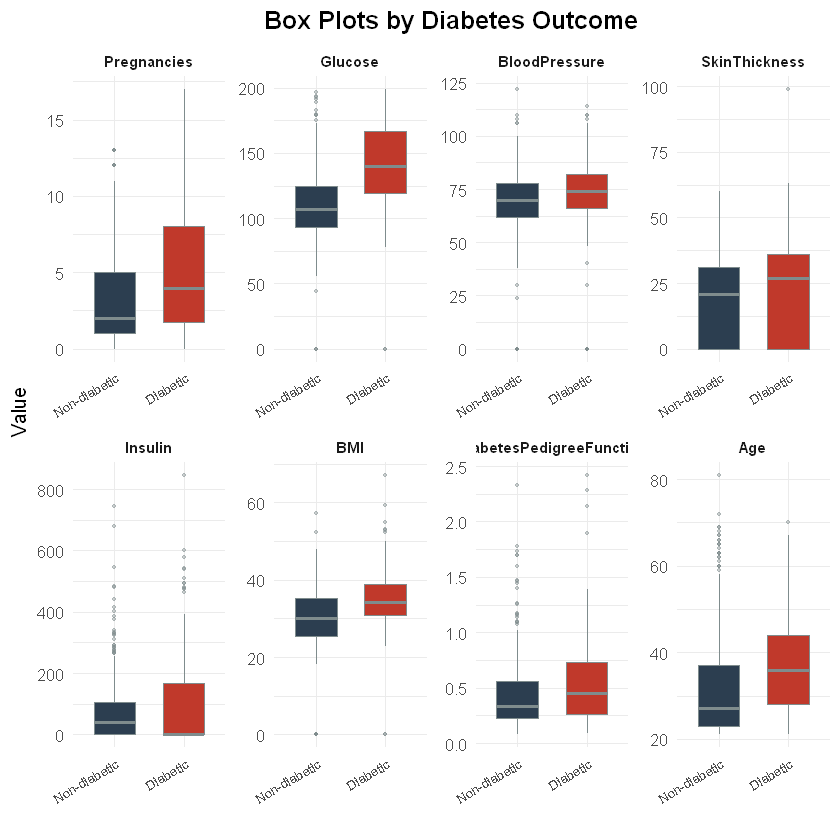

In [16]:
# ============================================================
# Box Plots by Outcome
# ============================================================

df_melt <- melt(diabetes[, c(features, "Outcome_f")], id.vars = "Outcome_f")

p_box <- ggplot(df_melt, aes(x = Outcome_f, y = value, fill = Outcome_f)) +
  geom_boxplot(outlier.size = 0.8, outlier.alpha = 0.4, width = 0.6,
               color = acad_grey) +
  facet_wrap(~ variable, scales = "free", ncol = 4) +
  scale_fill_manual(values = c(acad_blue, acad_red)) +
  labs(title = "Box Plots by Diabetes Outcome", x = "", y = "Value") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none",
        plot.title = element_text(face = "bold", hjust = 0.5, size = 15),
        axis.text.x = element_text(size = 8, angle = 30, hjust = 1),
        strip.text = element_text(size = 9, face = "bold"))
print(p_box)

## 2. Methods Used in Data Analysis

### 2.1 Probit Regression via Maximum Likelihood Estimation (MLE)

We employ **Probit regression**—which utilizes the cumulative distribution function of the standard normal distribution $\Phi(\cdot)$ as the inverse link—as an alternative to the logistic (logit) model:

$$P(Y_i = 1 \mid X_i) = \Phi(\beta_0 + \beta_1 X_{i1} + \dots + \beta_k X_{ik})$$

Parameters $\boldsymbol{\beta}$ are estimated by maximizing the log-likelihood:

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^n \big[ y_i \ln \Phi(\mathbf{x}_i^T \boldsymbol{\beta}) + (1 - y_i) \ln(1 - \Phi(\mathbf{x}_i^T \boldsymbol{\beta})) \big]$$

using iteratively reweighted least squares (IRLS).

### 2.2 EM Algorithm for Missing Data Imputation

Several features contain biologically implausible zero values (Glucose, BloodPressure, SkinThickness, Insulin, BMI). We treat these zeros as missing data and impute them via the **Expectation-Maximization (EM) algorithm** under a multivariate normal model:

**E-step**: Compute the conditional expectation of missing values $\mathbf{Z}_{\text{mis}}$ given observed data $\mathbf{Z}_{\text{obs}}$ and current parameter estimates $\boldsymbol{\theta}^{(t)}$:
$$E[\mathbf{Z}_{\text{mis}} \mid \mathbf{Z}_{\text{obs}}, \boldsymbol{\theta}^{(t)}]$$

**M-step**: Update parameters $\boldsymbol{\theta}^{(t+1)} = (\boldsymbol{\mu}, \boldsymbol{\Sigma})$ by maximizing the expected complete-data log-likelihood.

**Caveat**: The EM algorithm assumes multivariate normality, which is inappropriate for discrete/count variables (Pregnancies, Age, BloodPressure). For more rigorous imputation, one should consider multiple imputation via chained equations (MICE) with type-appropriate regression models (e.g., Poisson for counts, predictive mean matching for semi-continuous variables).

### 2.3 Bayesian Probit Regression via MCMC

We implement a full Bayesian Probit regression using the **Metropolis-Hastings (MH) algorithm**:

- **Likelihood**: $Y_i \sim \text{Bernoulli}(p_i), \quad p_i = \Phi(\mathbf{x}_i^T \boldsymbol{\beta})$
- **Prior**: $\beta_j \stackrel{\text{iid}}{\sim} N(0, \tau^2)$ with $\tau = 10$ (weakly informative)
- **Posterior**: $p(\boldsymbol{\beta} \mid \mathbf{y}, \mathbf{X}) \propto \prod_i \Phi(\mathbf{x}_i^T\boldsymbol{\beta})^{y_i}[1-\Phi(\mathbf{x}_i^T\boldsymbol{\beta})]^{1-y_i} \cdot \prod_j \exp\left(-\frac{\beta_j^2}{2\tau^2}\right)$

The MH sampler proposes $\boldsymbol{\beta}^* \sim N(\boldsymbol{\beta}^{(t)}, \sigma_p^2 \mathbf{I})$ with adaptive tuning of proposal variance to achieve optimal acceptance rates (~23.4%).

**Adaptation Strategy**: The proposal standard deviation is adjusted using a **sliding-window** acceptance rate (most recent 200 iterations) during burn-in, rather than the cumulative acceptance rate. This ensures faster response to the chain's current mixing behavior and avoids the inertia of early-iteration acceptance decisions.

## 3. Data Exploration and Statistical Analysis

### 3.1 Data Exploration & Preprocessing

Zero values in biologically-relevant features:
                   Variable Zero_Count Zero_Pct
Glucose             Glucose          5     0.65
BloodPressure BloodPressure         35     4.56
SkinThickness SkinThickness        227    29.56
Insulin             Insulin        374    48.70
BMI                     BMI         11     1.43


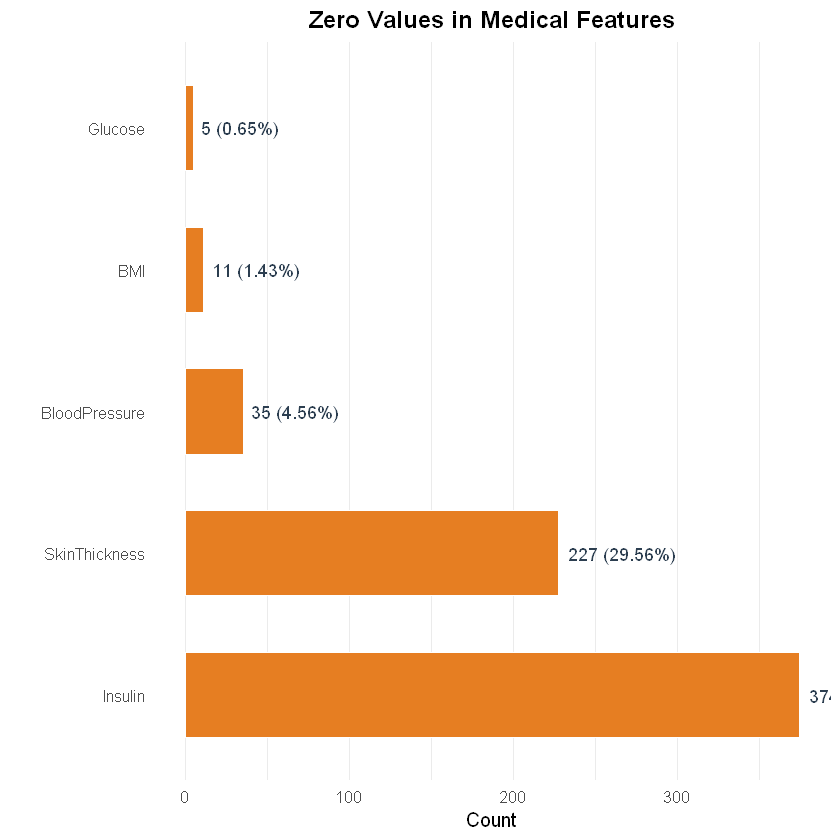

In [17]:
# 3.1.2  Zero-value Analysis

med_cols <- c('Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI')

zero_summary <- data.frame(
  Variable = med_cols,
  Zero_Count = sapply(med_cols, function(v) sum(diabetes[[v]] == 0)),
  Zero_Pct   = sapply(med_cols, function(v) round(sum(diabetes[[v]] == 0) / nrow(diabetes) * 100, 2))
)
cat("Zero values in biologically-relevant features:\n")
print(zero_summary)

p_zero <- ggplot(zero_summary, aes(x = reorder(Variable, -Zero_Count), y = Zero_Count, fill = Variable)) +
  geom_bar(stat = "identity", width = 0.6, fill = acad_orange, color = "white") +
  geom_text(aes(label = paste0(Zero_Count, " (", Zero_Pct, "%)")),
            hjust = -0.1, size = 3.8, color = acad_blue) +
  coord_flip() +
  labs(title = "Zero Values in Medical Features", x = "", y = "Count") +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        panel.grid.major.y = element_blank())
print(p_zero)

### 3.2 EM Algorithm for Missing Data Imputation

In [18]:
# 3.2 EM Algorithm for Missing Data Imputation (实际数据)

library(mvtnorm)   # 确保已加载

em_impute_mvn <- function(data, zero_cols, max_iter = 100, tol = 1e-6) {
  # 1. 仅使用数值列，去除因子/字符等非数值列
  num_cols <- names(data)[sapply(data, is.numeric)]
  if (length(num_cols) == 0) stop("数据中没有数值列，无法执行 EM 插补。")
  data <- data[, num_cols, drop = FALSE]  # 裁剪为纯数值数据框
  
  zero_cols <- intersect(zero_cols, num_cols)
  if (length(zero_cols) == 0) {
    warning("zero_cols 中没有有效的数值列，不进行任何插补。")
    return(list(imputed = data, loglik = NA))
  }
  
  # 2. 将指定列的 0 替换为 NA
  data_na <- data
  for (col in zero_cols) {
    data_na[data_na[[col]] == 0, col] <- NA
  }
  
  # 3. 初始插补：列均值
  data_imp <- data_na
  col_means <- colMeans(data_imp, na.rm = TRUE)
  for (col in zero_cols) {
    na_idx <- is.na(data_imp[[col]])
    if (any(na_idx)) data_imp[na_idx, col] <- col_means[col]
  }
  
  X <- as.matrix(data_imp)
  n <- nrow(X)
  p <- ncol(X)
  na_mask <- is.na(as.matrix(data_na))
  
  loglik_history <- numeric(max_iter)
  
  for (iter in 1:max_iter) {
    # E-step: 计算均值和协方差
    mu <- colMeans(X)
    X_centered <- sweep(X, 2, mu)
    Sigma <- (t(X_centered) %*% X_centered) / n
    
    # 用条件期望插补缺失值
    for (i in 1:n) {
      miss_idx <- which(na_mask[i, ])
      if (length(miss_idx) == 0) next
      obs_idx <- setdiff(1:p, miss_idx)
      
      if (length(obs_idx) == 0) {
        X[i, miss_idx] <- mu[miss_idx]
      } else {
        S_oo <- Sigma[obs_idx, obs_idx, drop = FALSE]
        S_mo <- Sigma[miss_idx, obs_idx, drop = FALSE]
        mu_m <- mu[miss_idx]
        mu_o <- mu[obs_idx]
        S_oo_reg <- S_oo + diag(1e-8, nrow(S_oo))
        cond_mean <- mu_m + S_mo %*% solve(S_oo_reg, X[i, obs_idx] - mu_o)
        X[i, miss_idx] <- cond_mean
      }
    }
    
    # 计算对数似然（基于观测数据）
    ll <- 0
    for (i in 1:n) {
      obs_idx <- which(!na_mask[i, ])
      if (length(obs_idx) > 0) {
        ll <- ll + dmvnorm(X[i, obs_idx], 
                           mean = mu[obs_idx],
                           sigma = Sigma[obs_idx, obs_idx, drop = FALSE],
                           log = TRUE)
      }
    }
    loglik_history[iter] <- ll
    
    if (iter > 1 && abs(loglik_history[iter] - loglik_history[iter - 1]) < tol) {
      cat(sprintf("EM 在第 %d 次迭代后收敛。\n", iter))
      break
    }
  }
  
  # 返回插补后的数据框
  imputed_num <- as.data.frame(X)
  colnames(imputed_num) <- num_cols
  return(list(imputed = imputed_num, loglik = loglik_history[1:iter]))
}

# ----------------------------------------------------------------------
# 使用真实 diabetes 数据运行 EM 插补
# ----------------------------------------------------------------------

# 1. 准备特征列（排除 Outcome、Outcome_f 和任何 ID 类列）
#    关键修正：ID 是无意义的行标识符，与糖尿病结局毫无因果关系，
#    将其纳入多元正态插补会引入虚假相关，扭曲缺失值的条件期望；
#    纳入回归模型会稀释真实预测因子的效应，导致系数估计偏误。
#    Outcome_f 是 factor 类型（Non-diabetic/Diabetic），非数值列，
#    必须排除，否则 colMeans() 会报错 'x' must be numeric。
exclude_cols <- c("Outcome", "Outcome_f", "ID", "id", "Id")
features <- setdiff(names(diabetes), exclude_cols)
# 同时过滤掉所有非数值列（双保险）
features <- intersect(features, names(diabetes)[sapply(diabetes, is.numeric)])
cat("参与 EM 插补的特征列：\n")
print(features)

# 2. 执行 EM 插补（仅对特征列进行，零值仅在 med_cols 中视为缺失）
cat("\n运行 EM 插补...\n")
em_result <- em_impute_mvn(diabetes[, features], med_cols, max_iter = 200, tol = 1e-6)

# 3. 将插补结果合并回原始数据框
diabetes_em <- diabetes
diabetes_em[, features] <- em_result$imputed

# 4. 查看插补后指定列（原 zero_cols）的统计摘要
cat("\n插补后（med_cols）列的最小值、中位数、最大值：\n")
for (col in med_cols) {
  cat(sprintf("  %s: min=%.2f, median=%.2f, max=%.2f\n",
              col, min(diabetes_em[[col]]), median(diabetes_em[[col]]),
              max(diabetes_em[[col]])))
}

# 5. 检查原始数据中这些列的零值个数（即缺失数）
cat("\n原始数据中 med_cols 的零值个数（被视为缺失）：\n")
for (col in med_cols) {
  cat(sprintf("  %s: %d\n", col, sum(diabetes[[col]] == 0)))
}

# 6. 查看插补后数据的前几行（含 Outcome）
cat("\n插补后数据的前 6 行：\n")
print(head(diabetes_em))


参与 EM 插补的特征列：
[1] "Pregnancies"              "Glucose"                 
[3] "BloodPressure"            "SkinThickness"           
[5] "Insulin"                  "BMI"                     
[7] "DiabetesPedigreeFunction" "Age"                     

运行 EM 插补...
EM 在第 27 次迭代后收敛。

插补后（med_cols）列的最小值、中位数、最大值：
  Glucose: min=44.00, median=117.00, max=199.00
  BloodPressure: min=24.00, median=72.00, max=122.00
  SkinThickness: min=7.00, median=28.39, max=99.00
  Insulin: min=-20.87, median=130.00, max=846.00
  BMI: min=18.20, median=32.05, max=67.10

原始数据中 med_cols 的零值个数（被视为缺失）：
  Glucose: 5
  BloodPressure: 35
  SkinThickness: 227
  Insulin: 374
  BMI: 11

插补后数据的前 6 行：
  Pregnancies Glucose BloodPressure SkinThickness   Insulin  BMI
1           6     148            72      35.00000 222.87441 33.6
2           1      85            66      29.00000  69.74403 26.6
3           8     183            64      21.39351 258.52503 23.3
4           1      89            66      23.00000  94.00000 28.1
5   

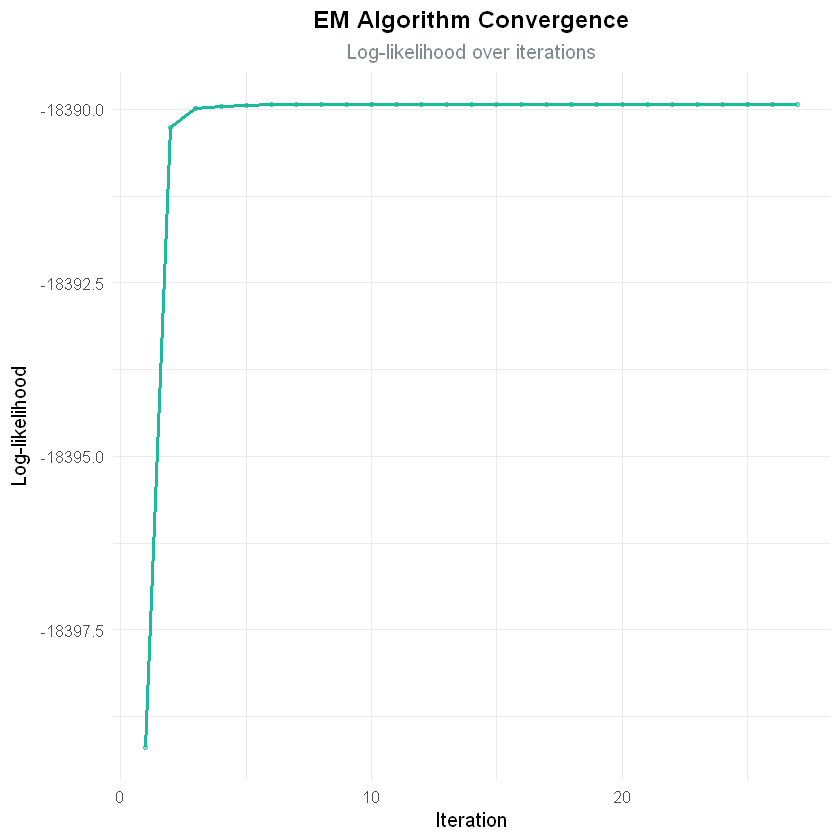

In [19]:
# EM Log-likelihood Convergence Plot

ll_df <- data.frame(
  Iteration = 1:length(em_result$loglik),
  LogLikelihood = em_result$loglik
)

p_em <- ggplot(ll_df, aes(x = Iteration, y = LogLikelihood)) +
  geom_line(color = acad_teal, size = 1) +
  geom_point(size = 1, color = acad_teal, alpha = 0.5) +
  labs(title = "EM Algorithm Convergence",
       subtitle = "Log-likelihood over iterations",
       x = "Iteration", y = "Log-likelihood") +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5, color = acad_grey))
print(p_em)

### 3.3 Data Splitting and Standardization

In [20]:
# Train-Test Split & Standardization

# Prepare data — 强制 y 为数值型 0/1，避免因子类型导致 mean() 输出 NA
X <- diabetes_em[, features]
y <- as.numeric(as.character(diabetes_em$Outcome))
stopifnot(all(y %in% c(0, 1)))

cat(sprintf("Total samples: %d\n", nrow(X)))
cat(sprintf("Class balance: %.1f%% positive\n", mean(y) * 100))

# Train-test split (70/30, stratified)
set.seed(42)
train_idx <- createDataPartition(y, p = 0.7, list = FALSE)
X_train <- X[train_idx, ]
X_test  <- X[-train_idx, ]
y_train <- y[train_idx]
y_test  <- y[-train_idx]

# Standardize features
train_means <- colMeans(X_train)
train_sds   <- apply(X_train, 2, sd)

X_train_sc <- scale(X_train, center = train_means, scale = train_sds)
X_test_sc  <- scale(X_test, center = train_means, scale = train_sds)

cat(sprintf("\nTraining set:   %d samples (%.1f%% positive)\n",
            nrow(X_train_sc), mean(y_train) * 100))
cat(sprintf("Test set:       %d samples (%.1f%% positive)\n",
            nrow(X_test_sc), mean(y_test) * 100))

Total samples: 768
Class balance: 34.9% positive

Training set:   538 samples (35.9% positive)
Test set:       230 samples (32.6% positive)


### 3.4 Probit Regression (Maximum Likelihood Estimation)

In [21]:
# Probit Regression via MLE

probit_model <- glm(y_train ~ ., data = as.data.frame(X_train_sc),
                    family = binomial(link = "probit"))

cat("===== Probit Regression Results (MLE) =====\n")
cat("\nCoefficients:\n")
print(summary(probit_model)$coefficients)

# Predictions
y_prob_probit <- predict(probit_model, as.data.frame(X_test_sc), type = "response")
y_pred_probit <- ifelse(y_prob_probit >= 0.5, 1, 0)

# Metrics
acc_probit <- mean(y_pred_probit == y_test)
auc_probit <- roc(y_test, y_prob_probit, quiet = TRUE)$auc
cm_probit   <- table(Predicted = y_pred_probit, Actual = y_test)

cat(sprintf("\nAccuracy: %.4f\n", acc_probit))
cat(sprintf("AUC:      %.4f\n", auc_probit))
cat("\nConfusion Matrix:\n")
print(cm_probit)

===== Probit Regression Results (MLE) =====

Coefficients:
                            Estimate Std. Error    z value     Pr(>|z|)
(Intercept)              -0.49014732 0.06585166 -7.4432036 9.827247e-14
Pregnancies               0.24881347 0.07363885  3.3788345 7.279381e-04
Glucose                   0.75282244 0.09765737  7.7088131 1.269933e-14
BloodPressure            -0.05734191 0.07179247 -0.7987176 4.244542e-01
SkinThickness             0.09820792 0.09852410  0.9967909 3.188660e-01
Insulin                  -0.13803865 0.09082303 -1.5198640 1.285452e-01
BMI                       0.34537396 0.10044838  3.4383228 5.853295e-04
DiabetesPedigreeFunction  0.14501170 0.06820332  2.1261677 3.348930e-02
Age                       0.09470395 0.07918589  1.1959701 2.317082e-01

Accuracy: 0.7826
AUC:      0.8304

Confusion Matrix:
         Actual
Predicted   0   1
        0 136  31
        1  19  44


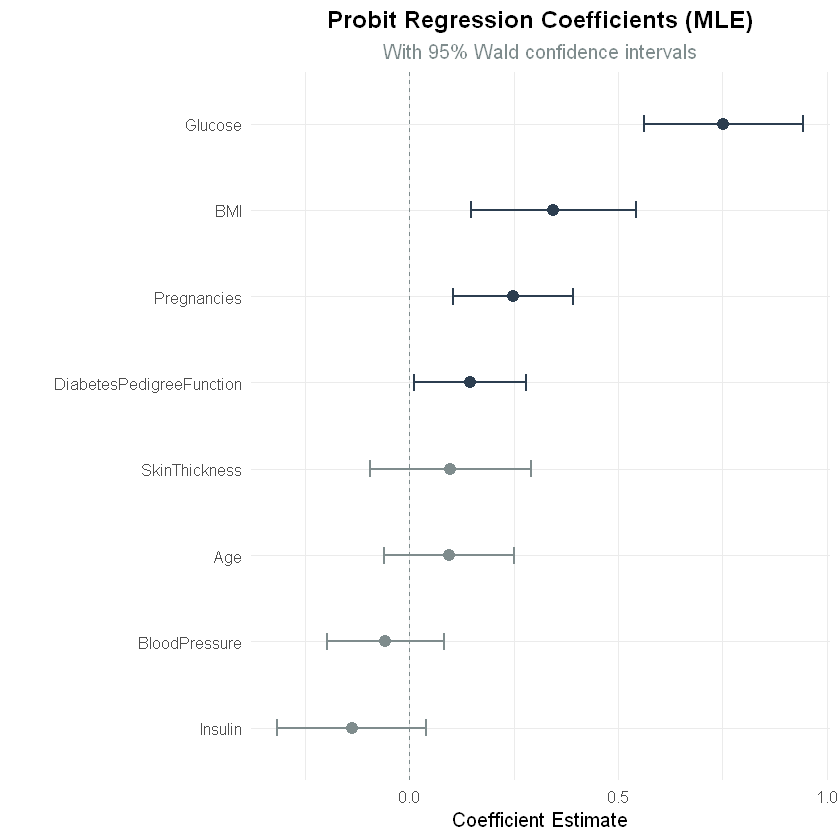

In [22]:
# Probit Coefficient Plot
coef_df <- data.frame(
  Variable  = names(coef(probit_model)),
  Estimate  = coef(probit_model),
  SE        = summary(probit_model)$coefficients[, 2]
)
coef_df$Lower <- coef_df$Estimate - 1.96 * coef_df$SE
coef_df$Upper <- coef_df$Estimate + 1.96 * coef_df$SE
coef_df <- coef_df[coef_df$Variable != "(Intercept)", ]
coef_df$Significant <- ifelse(coef_df$Lower > 0 | coef_df$Upper < 0, "Yes", "No")

p_coef <- ggplot(coef_df, aes(x = reorder(Variable, Estimate), y = Estimate,
                               color = Significant)) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = Lower, ymax = Upper), width = 0.2, size = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed", color = acad_grey, size = 0.5) +
  scale_color_manual(values = c("No" = acad_grey, "Yes" = acad_blue)) +
  coord_flip() +
  labs(title = "Probit Regression Coefficients (MLE)",
       subtitle = "With 95% Wald confidence intervals",
       x = "", y = "Coefficient Estimate") +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        plot.subtitle = element_text(hjust = 0.5, color = acad_grey),
        legend.position = "none")
print(p_coef)

### 3.5 Bayesian Probit Regression via Metropolis-Hastings MCMC

In [23]:
# ============================================================
# 3.5 Bayesian Probit Regression via Metropolis-Hastings MCMC
# 关键修正：自适应调整改用滑动窗口接受率（最近 200 步），
#           而非从第 1 步累计的接受率，以更快响应链的当前状态。
# ============================================================

bayesian_probit_mh <- function(X, y, n_iter = 15000, burn_in = 5000,
                                prior_sd = 10, init_proposal_sd = 0.05,
                                window_size = 200, verbose = TRUE) {
  # ---- 强制 y 为数值 0/1 ----
  if (is.factor(y)) {
    y <- as.numeric(as.character(y))
  } else {
    y <- as.numeric(y)
  }
  if (!all(y %in% c(0, 1))) {
    stop("响应变量 y 必须为二值 0 或 1")
  }
  # ---------------------------
  
  X_design <- cbind(1, as.matrix(X))
  n <- nrow(X_design)
  p <- ncol(X_design)
  
  # MLE 初始化
  init_fit <- glm(y ~ as.matrix(X), family = binomial(link = "probit"))
  beta_current <- coef(init_fit)
  
  # 对数后验
  log_posterior <- function(beta) {
    eta <- X_design %*% beta
    prob <- pnorm(eta)
    prob <- pmax(pmin(prob, 1 - 1e-12), 1e-12)
    log_lik <- sum(y * log(prob) + (1 - y) * log(1 - prob))
    log_prior <- sum(dnorm(beta, 0, prior_sd, log = TRUE))
    return(log_lik + log_prior)
  }
  
  chain <- matrix(NA, nrow = n_iter, ncol = p)
  colnames(chain) <- c("Intercept", colnames(X))
  accept_count <- 0
  accept_history <- logical(n_iter)  # 记录每次是否接受
  proposal_sd <- init_proposal_sd
  log_post_current <- log_posterior(beta_current)
  
  for (i in 1:n_iter) {
    beta_proposal <- beta_current + rnorm(p, 0, proposal_sd)
    log_post_proposal <- log_posterior(beta_proposal)
    log_alpha <- log_post_proposal - log_post_current
    
    if (log(runif(1)) < log_alpha) {
      beta_current <- beta_proposal
      log_post_current <- log_post_proposal
      accept_history[i] <- TRUE
      accept_count <- accept_count + 1
    } else {
      accept_history[i] <- FALSE
    }
    chain[i, ] <- beta_current
    
    # 自适应调整（仅 burn-in 阶段）：使用滑动窗口接受率
    if (i <= burn_in && i %% 50 == 0 && i > window_size) {
      recent_accept <- accept_history[(i - window_size + 1):i]
      acc_rate <- mean(recent_accept)
      if (acc_rate < 0.20) proposal_sd <- proposal_sd * 0.9
      else if (acc_rate > 0.35) proposal_sd <- proposal_sd * 1.1
    }
  }
  
  accept_rate <- accept_count / n_iter
  post_samples <- chain[(burn_in + 1):n_iter, ]
  
  if (verbose) {
    cat("MCMC Sampling Complete:\n")
    cat(sprintf("  Total iterations: %d\n", n_iter))
    cat(sprintf("  Burn-in:          %d\n", burn_in))
    cat(sprintf("  Posterior samples: %d\n", nrow(post_samples)))
    cat(sprintf("  Acceptance rate:  %.2f%%\n", accept_rate * 100))
    cat(sprintf("  Final proposal SD: %.4f\n", proposal_sd))
    if (accept_rate < 0.15) {
      cat("  WARNING: 接受率偏低（<15%），建议调整 proposal SD 或增加迭代次数。\n")
    }
  }
  
  return(list(chain = chain, samples = post_samples,
              accept_rate = accept_rate, proposal_sd = proposal_sd))
}

# ---- 运行 MCMC ----
cat("Running Bayesian Probit MCMC...\n")
bayes_fit <- bayesian_probit_mh(X_train_sc, y_train,
                                 n_iter = 20000, burn_in = 5000,
                                 prior_sd = 10, init_proposal_sd = 0.05)

Running Bayesian Probit MCMC...
MCMC Sampling Complete:
  Total iterations: 20000
  Burn-in:          5000
  Posterior samples: 15000
  Acceptance rate:  29.84%
  Final proposal SD: 0.0485


In [24]:
# Posterior Summary Statistics
post_mean   <- colMeans(bayes_fit$samples)
post_median <- apply(bayes_fit$samples, 2, median)
post_sd     <- apply(bayes_fit$samples, 2, sd)

# Compute 95% HPD intervals manually
compute_hpd <- function(samples, cred_mass = 0.95) {
  sorted <- sort(samples)
  n <- length(sorted)
  window_size <- floor(cred_mass * n)
  best_low <- sorted[1]
  best_high <- sorted[window_size]
  best_width <- best_high - best_low
  for (i in 1:(n - window_size)) {
    w <- sorted[i + window_size] - sorted[i]
    if (w < best_width) {
      best_width <- w
      best_low <- sorted[i]
      best_high <- sorted[i + window_size]
    }
  }
  return(c(best_low, best_high))
}

hpd_intervals <- t(apply(bayes_fit$samples, 2, compute_hpd))
colnames(hpd_intervals) <- c("HPD_Lower", "HPD_Upper")

# Significant 判定：HPD 区间不跨零（下界和上界同号）
summary_df <- data.frame(
  Parameter   = colnames(bayes_fit$samples),
  Post_Mean   = round(post_mean, 4),
  Post_Median = round(post_median, 4),
  Post_SD     = round(post_sd, 4),
  HPD_Lower   = round(hpd_intervals[, 1], 4),
  HPD_Upper   = round(hpd_intervals[, 2], 4),
  HPD_Crosses_Zero = ifelse(hpd_intervals[, 1] * hpd_intervals[, 2] <= 0, "Yes", "No")
)

cat("===== Bayesian Probit Regression - Posterior Summary =====\n")
cat("(HPD_Crosses_Zero = Yes 表示 95% 可信区间包含 0，效应方向不确定)\n\n")
print(summary_df, row.names = FALSE)

===== Bayesian Probit Regression - Posterior Summary =====
(HPD_Crosses_Zero = Yes 表示 95% 可信区间包含 0，效应方向不确定)

                Parameter Post_Mean Post_Median Post_SD HPD_Lower HPD_Upper
                Intercept   -0.4881     -0.4880  0.0673   -0.6298   -0.3616
              Pregnancies    0.2487      0.2482  0.0744    0.1059    0.3921
                  Glucose    0.7667      0.7626  0.0934    0.5933    0.9561
            BloodPressure   -0.0646     -0.0623  0.0711   -0.2051    0.0692
            SkinThickness    0.1011      0.0985  0.0963   -0.0736    0.3006
                  Insulin   -0.1462     -0.1438  0.0851   -0.3190    0.0203
                      BMI    0.3496      0.3549  0.1014    0.1497    0.5403
 DiabetesPedigreeFunction    0.1410      0.1430  0.0639    0.0140    0.2637
                      Age    0.0989      0.0997  0.0792   -0.0487    0.2603
 HPD_Crosses_Zero
               No
               No
               No
              Yes
              Yes
              Yes
     

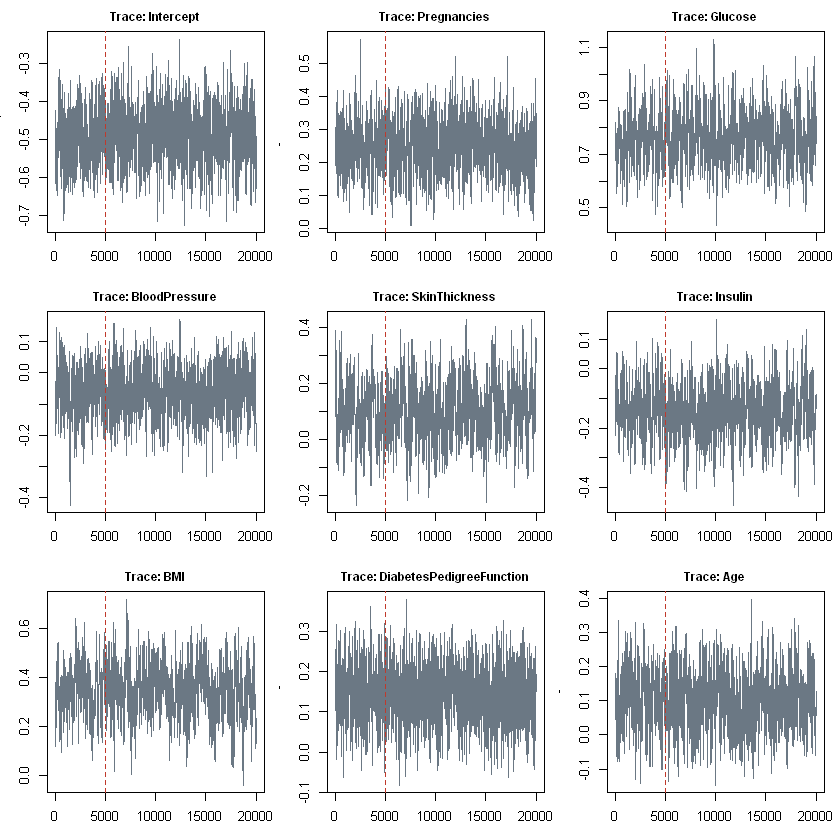

In [25]:
# MCMC Trace Plots

param_names <- colnames(bayes_fit$chain)
n_params <- length(param_names)
n_cols <- 3
n_rows <- ceiling(n_params / n_cols)

par(mfrow = c(n_rows, n_cols), mar = c(3, 3, 2, 1))
for (i in 1:n_params) {
  plot(bayes_fit$chain[, i], type = "l", col = adjustcolor(acad_blue, 0.7),
       xlab = "Iteration", ylab = param_names[i],
       main = paste("Trace:", param_names[i]), cex.main = 0.9)
  abline(v = 5000, col = acad_red, lty = 2, lwd = 1.5)
}
par(mfrow = c(1, 1))

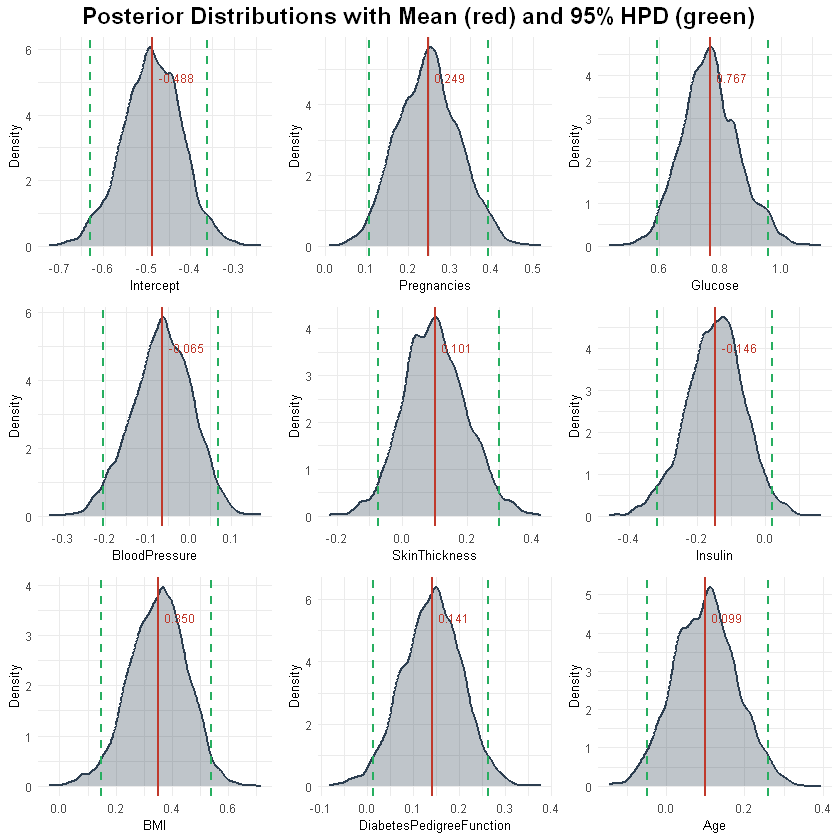

In [26]:
# Posterior Density Plots

plot_list_post <- list()
for (i in 1:n_params) {
  df_i <- data.frame(Value = bayes_fit$samples[, i])
  hpd <- compute_hpd(bayes_fit$samples[, i])
  
  p <- ggplot(df_i, aes(x = Value)) +
    geom_density(fill = adjustcolor(acad_blue, 0.3), 
                 color = acad_blue, size = 0.6) +
    geom_vline(xintercept = post_mean[i], color = acad_red,
               linetype = "solid", size = 0.8) +
    geom_vline(xintercept = hpd, color = acad_green,
               linetype = "dashed", size = 0.6) +
    annotate("text", x = post_mean[i], 
             y = max(density(bayes_fit$samples[, i])$y) * 0.85,
             label = sprintf("%.3f", post_mean[i]),
             color = acad_red, size = 2.5, hjust = -0.2) +
    labs(x = param_names[i], y = "Density") +
    theme_minimal(base_size = 9) +
    theme(axis.title = element_text(size = 8))
  plot_list_post[[i]] <- p
}

grid.arrange(grobs = plot_list_post, ncol = 3,
             top = grid::textGrob("Posterior Distributions with Mean (red) and 95% HPD (green)",
                                  gp = grid::gpar(fontface = "bold", fontsize = 14),
                                  vjust = 0.5))

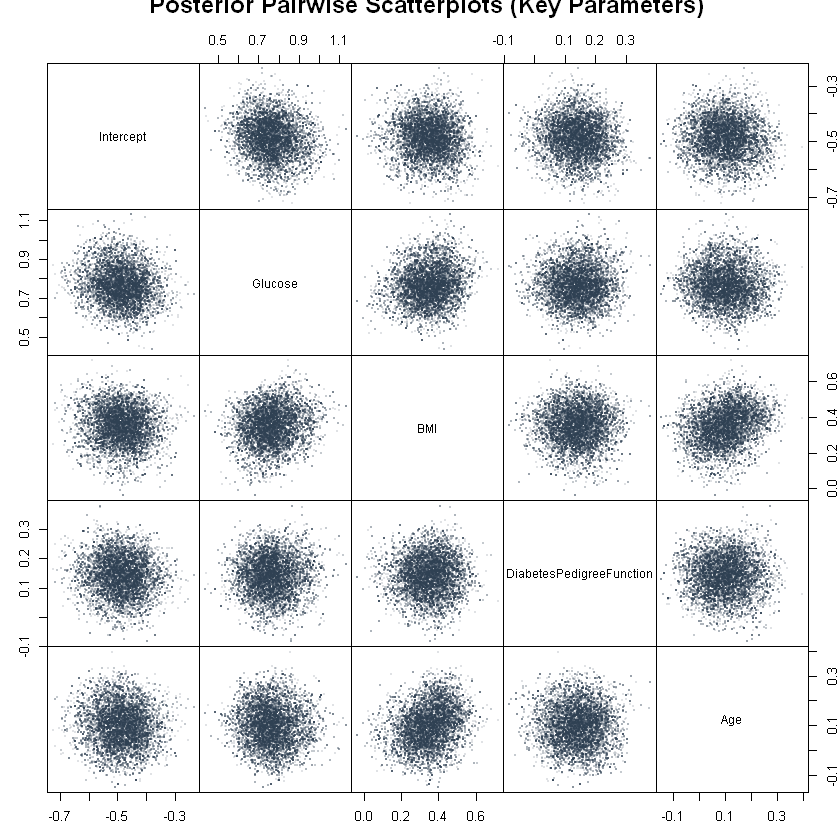

In [27]:
# Pairwise Posterior Scatterplots

# Select key parameters for pairwise plot
key_params <- c("Intercept", "Glucose", "BMI", "DiabetesPedigreeFunction", "Age")
df_pairs <- as.data.frame(bayes_fit$samples[, key_params])

plot(df_pairs, pch = 16, col = adjustcolor(acad_blue, 0.15),
     cex = 0.3, main = "Posterior Pairwise Scatterplots (Key Parameters)",
     gap = 0, oma = c(3, 3, 4, 2))

In [28]:
# Bayesian Predictions & Uncertainty Quantification

X_test_design <- cbind(1, as.matrix(X_test_sc))
n_post <- nrow(bayes_fit$samples)
n_test <- nrow(X_test_design)

# Predictive probabilities for each posterior sample
pred_matrix <- matrix(NA, nrow = n_post, ncol = n_test)
for (s in 1:n_post) {
  eta <- X_test_design %*% bayes_fit$samples[s, ]
  pred_matrix[s, ] <- pnorm(eta)
}

# Posterior mean predictions
y_prob_bayes <- colMeans(pred_matrix)
y_pred_bayes <- ifelse(y_prob_bayes >= 0.5, 1, 0)

# 95% credible intervals for each prediction
prob_lower <- apply(pred_matrix, 2, quantile, 0.025)
prob_upper <- apply(pred_matrix, 2, quantile, 0.975)

# Metrics
acc_bayes <- mean(y_pred_bayes == y_test)
auc_bayes <- roc(y_test, y_prob_bayes, quiet = TRUE)$auc
cm_bayes  <- table(Predicted = y_pred_bayes, Actual = y_test)

cat("===== Bayesian Probit Results =====\n")
cat(sprintf("Accuracy: %.4f\n", acc_bayes))
cat(sprintf("AUC:      %.4f\n", auc_bayes))
cat("\nConfusion Matrix:\n")
print(cm_bayes)

# Show some predictions with credible intervals
pred_display <- data.frame(
  True   = y_test[1:15],
  Prob   = round(y_prob_bayes[1:15], 4),
  Pred   = y_pred_bayes[1:15],
  CI_Low = round(prob_lower[1:15], 4),
  CI_High = round(prob_upper[1:15], 4)
)
cat("\nFirst 15 test predictions (with 95% credible intervals):\n")
print(pred_display, row.names = FALSE)

===== Bayesian Probit Results =====
Accuracy: 0.7826
AUC:      0.8297

Confusion Matrix:
         Actual
Predicted   0   1
        0 136  31
        1  19  44

First 15 test predictions (with 95% credible intervals):
 True   Prob Pred CI_Low CI_High
    1 0.7134    1 0.6288  0.7944
    0 0.0283    0 0.0120  0.0518
    1 0.8515    1 0.6152  0.9770
    0 0.1443    0 0.0913  0.2037
    1 0.7760    1 0.5583  0.9311
    0 0.7328    1 0.5557  0.8692
    0 0.3799    0 0.1653  0.6388
    0 0.4500    0 0.3362  0.5676
    0 0.0252    0 0.0093  0.0513
    0 0.6084    1 0.4277  0.7667
    0 0.0290    0 0.0066  0.0720
    0 0.1368    0 0.0595  0.2463
    1 0.4041    0 0.2927  0.5197
    0 0.1109    0 0.0471  0.1965
    1 0.9479    1 0.8562  0.9899


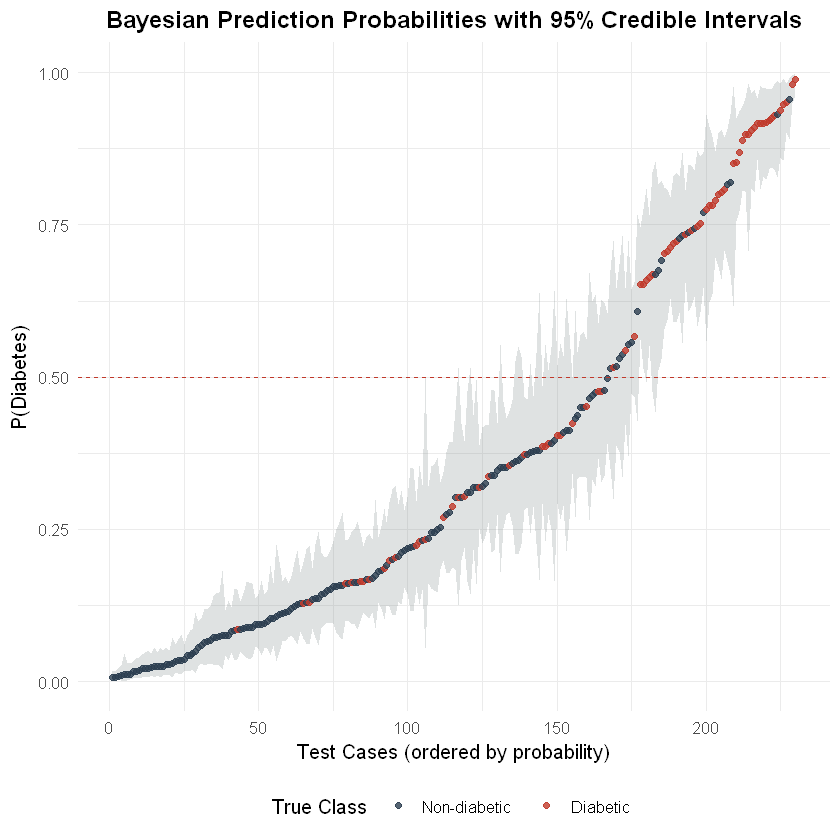

In [29]:
# Prediction Uncertainty Visualization

idx <- order(y_prob_bayes)
df_pred <- data.frame(
  Index   = 1:n_test,
  Prob    = y_prob_bayes[idx],
  Lower   = prob_lower[idx],
  Upper   = prob_upper[idx],
  True    = factor(y_test[idx], levels = c(0, 1),
                   labels = c("Non-diabetic", "Diabetic"))
)

p_pred <- ggplot(df_pred, aes(x = Index, y = Prob, color = True)) +
  geom_ribbon(aes(ymin = Lower, ymax = Upper), fill = acad_grey, alpha = 0.25,
              color = NA) +
  geom_point(size = 1.5, alpha = 0.8) +
  geom_hline(yintercept = 0.5, linetype = "dashed", color = acad_red, size = 0.5) +
  scale_color_manual(values = c(acad_blue, acad_red)) +
  labs(title = "Bayesian Prediction Probabilities with 95% Credible Intervals",
       x = "Test Cases (ordered by probability)", y = "P(Diabetes)",
       color = "True Class") +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        legend.position = "bottom")
print(p_pred)

### 3.6 Comparison of Different Methods

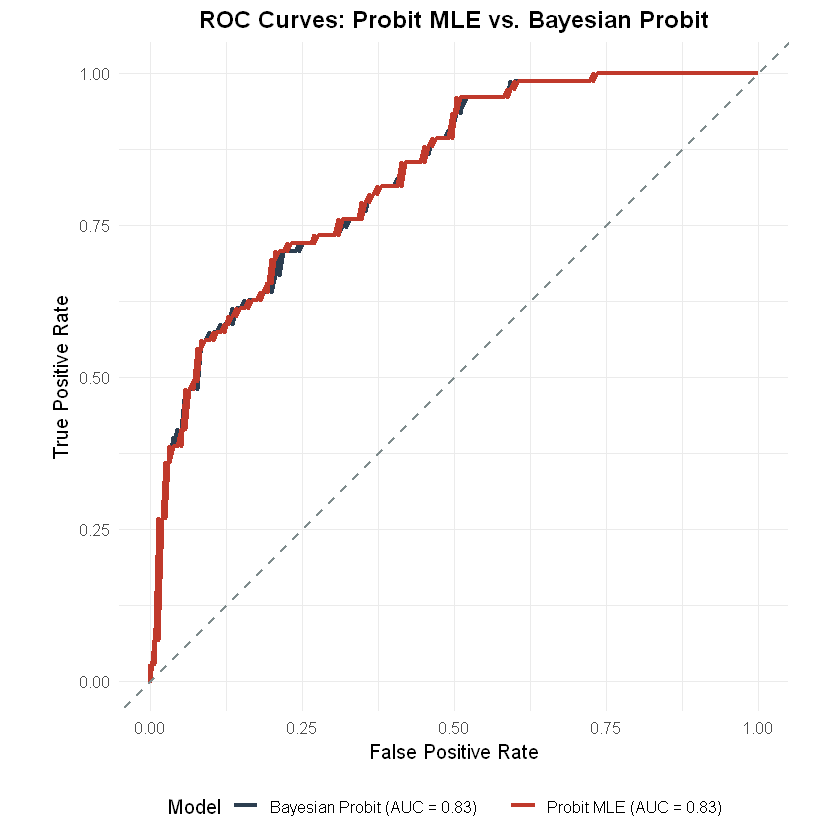

In [30]:
# Model Comparison: ROC Curves

roc_probit <- roc(y_test, y_prob_probit, quiet = TRUE)
roc_bayes  <- roc(y_test, y_prob_bayes, quiet = TRUE)

df_roc <- rbind(
  data.frame(FPR = 1 - roc_probit$specificities, TPR = roc_probit$sensitivities,
             Model = paste0("Probit MLE (AUC = ", round(auc_probit, 3), ")")),
  data.frame(FPR = 1 - roc_bayes$specificities, TPR = roc_bayes$sensitivities,
             Model = paste0("Bayesian Probit (AUC = ", round(auc_bayes, 3), ")"))
)

p_roc <- ggplot(df_roc, aes(x = FPR, y = TPR, color = Model)) +
  geom_line(size = 1.2) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed",
              color = acad_grey, size = 0.6) +
  scale_color_manual(values = c(acad_blue, acad_red)) +
  coord_equal() +
  labs(title = "ROC Curves: Probit MLE vs. Bayesian Probit",
       x = "False Positive Rate", y = "True Positive Rate") +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        legend.position = "bottom")
print(p_roc)

In [31]:
# Comprehensive Comparison Table

comparison <- data.frame(
  Metric    = c("Accuracy", "AUC", "Sensitivity", "Specificity", "Precision"),
  Probit_MLE = c(
    round(acc_probit, 4),
    round(auc_probit, 4),
    round(cm_probit[2, 2] / sum(cm_probit[, 2]), 4),
    round(cm_probit[1, 1] / sum(cm_probit[, 1]), 4),
    round(cm_probit[2, 2] / sum(cm_probit[2, ]), 4)
  ),
  Bayesian_MCMC = c(
    round(acc_bayes, 4),
    round(auc_bayes, 4),
    round(cm_bayes[2, 2] / sum(cm_bayes[, 2]), 4),
    round(cm_bayes[1, 1] / sum(cm_bayes[, 1]), 4),
    round(cm_bayes[2, 2] / sum(cm_bayes[2, ]), 4)
  )
)

cat("\n========== Model Comparison ==========\n")
print(comparison, row.names = FALSE)

cat("\n========== Methodological Comparison ==========\n")
method_comp <- data.frame(
  Aspect       = c("Parameter Estimate", "Uncertainty", "Computational Cost",
                    "Prior Information", "Inference Scope"),
  Probit_MLE   = c("Point estimate", "Wald confidence intervals",
                    "Very fast", "Not incorporated", "Frequentist hypothesis testing"),
  Bayesian_MCMC = c("Posterior distribution", "Full posterior + HPD intervals",
                     "Moderate (MCMC sampling)", "Can incorporate prior knowledge",
                     "Posterior probabilities + credible intervals")
)
print(method_comp, row.names = FALSE)


========== Model Comparison ==========
      Metric Probit_MLE Bayesian_MCMC
    Accuracy     0.7826        0.7826
         AUC     0.8304        0.8297
 Sensitivity     0.5867        0.5867
 Specificity     0.8774        0.8774
   Precision     0.6984        0.6984

========== Methodological Comparison ==========
             Aspect                     Probit_MLE
 Parameter Estimate                 Point estimate
        Uncertainty      Wald confidence intervals
 Computational Cost                      Very fast
  Prior Information               Not incorporated
    Inference Scope Frequentist hypothesis testing
                                Bayesian_MCMC
                       Posterior distribution
               Full posterior + HPD intervals
                     Moderate (MCMC sampling)
              Can incorporate prior knowledge
 Posterior probabilities + credible intervals


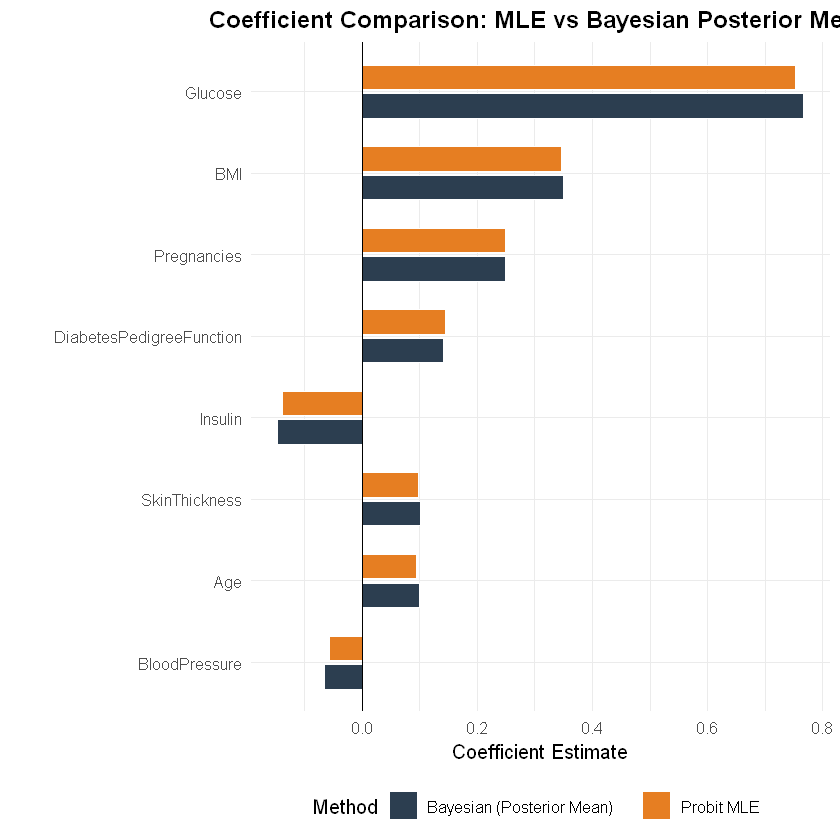

In [32]:
# Coefficient Comparison: MLE vs Bayesian Posterior

probit_coefs <- coef(probit_model)[-1]
bayes_post_mean <- post_mean[-1]
bayes_post_sd <- post_sd[-1]

coef_comp <- data.frame(
  Feature    = names(probit_coefs),
  MLE        = probit_coefs,
  Bayes_Mean = bayes_post_mean,
  Bayes_SD   = bayes_post_sd
)

coef_long <- rbind(
  data.frame(Feature = coef_comp$Feature, Value = coef_comp$MLE,
             Method = "Probit MLE"),
  data.frame(Feature = coef_comp$Feature, Value = coef_comp$Bayes_Mean,
             Method = "Bayesian (Posterior Mean)")
)

p_comp <- ggplot(coef_long, aes(x = reorder(Feature, abs(Value)), y = Value,
                                fill = Method)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.7),
           width = 0.6, color = "white", size = 0.2) +
  geom_hline(yintercept = 0, size = 0.5) +
  scale_fill_manual(values = c(acad_blue, acad_orange)) +
  coord_flip() +
  labs(title = "Coefficient Comparison: MLE vs Bayesian Posterior Mean",
       x = "", y = "Coefficient Estimate") +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        legend.position = "bottom")
print(p_comp)

Feature Importance Ranking (Bayesian Posterior):
                  Feature   Coef_Mean Direction
                  Glucose  0.76668442  Positive
                      BMI  0.34955293  Positive
              Pregnancies  0.24865523  Positive
                  Insulin -0.14615369  Negative
 DiabetesPedigreeFunction  0.14096791  Positive
            SkinThickness  0.10113483  Positive
                      Age  0.09889617  Positive
            BloodPressure -0.06459340  Negative


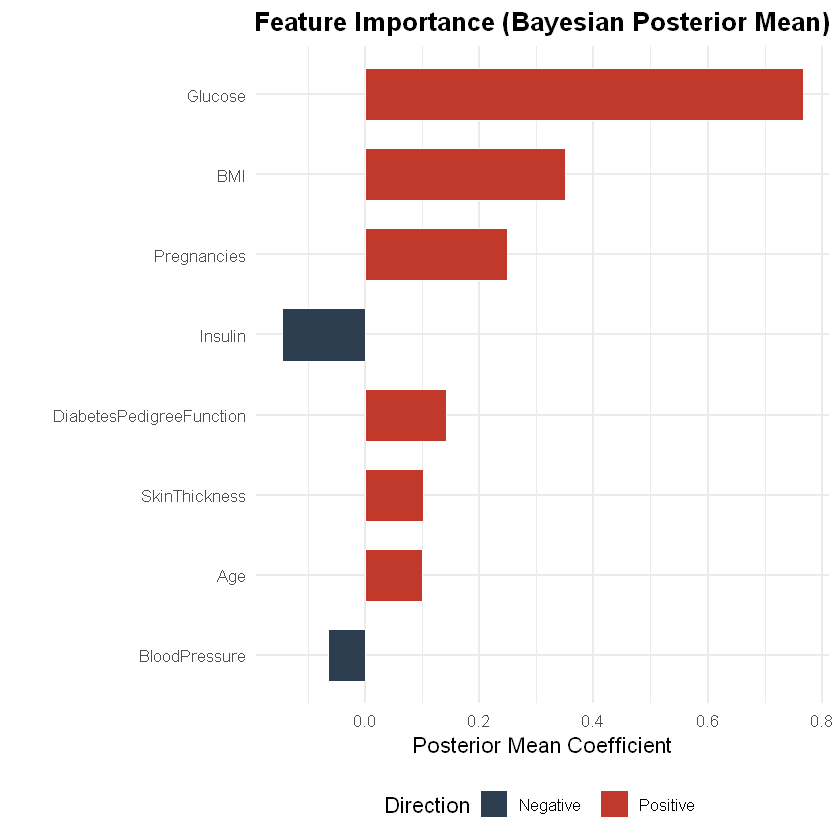

In [33]:
# Posterior Feature Importance (based on |posterior mean|)
importance_df <- data.frame(
  Feature   = features,
  Coef_Mean = post_mean[-1],
  Abs_Mean  = abs(post_mean[-1])
)
importance_df <- importance_df[order(-importance_df$Abs_Mean), ]
importance_df$Direction <- ifelse(importance_df$Coef_Mean > 0, "Positive", "Negative")

cat("Feature Importance Ranking (Bayesian Posterior):\n")
print(importance_df[, c("Feature", "Coef_Mean", "Direction")], row.names = FALSE)

p_imp <- ggplot(importance_df, aes(x = reorder(Feature, Abs_Mean), y = Coef_Mean,
                                    fill = Direction)) +
  geom_bar(stat = "identity", width = 0.65, color = "white", size = 0.3) +
  scale_fill_manual(values = c("Positive" = acad_red, "Negative" = acad_blue)) +
  coord_flip() +
  labs(title = "Feature Importance (Bayesian Posterior Mean)",
       x = "", y = "Posterior Mean Coefficient") +
  theme_minimal(base_size = 13) +
  theme(plot.title = element_text(face = "bold", hjust = 0.5),
        legend.position = "bottom")
print(p_imp)

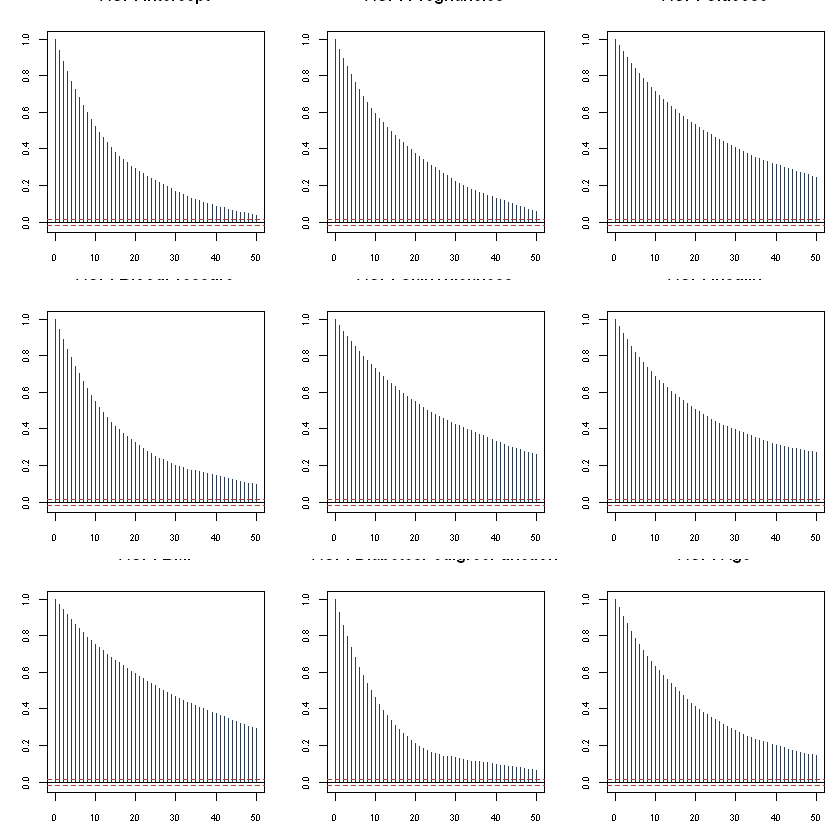

In [34]:
# MCMC Convergence Diagnostics (Autocorrelation)

par(mfrow = c(n_rows, n_cols), mar = c(3, 3, 2, 1))
for (i in 1:n_params) {
  acf(bayes_fit$samples[, i], lag.max = 50,
      main = paste("ACF:", param_names[i]),
      ci.col = acad_red, col = acad_blue,
      cex.main = 0.85, cex.axis = 0.7)
}
par(mfrow = c(1, 1))

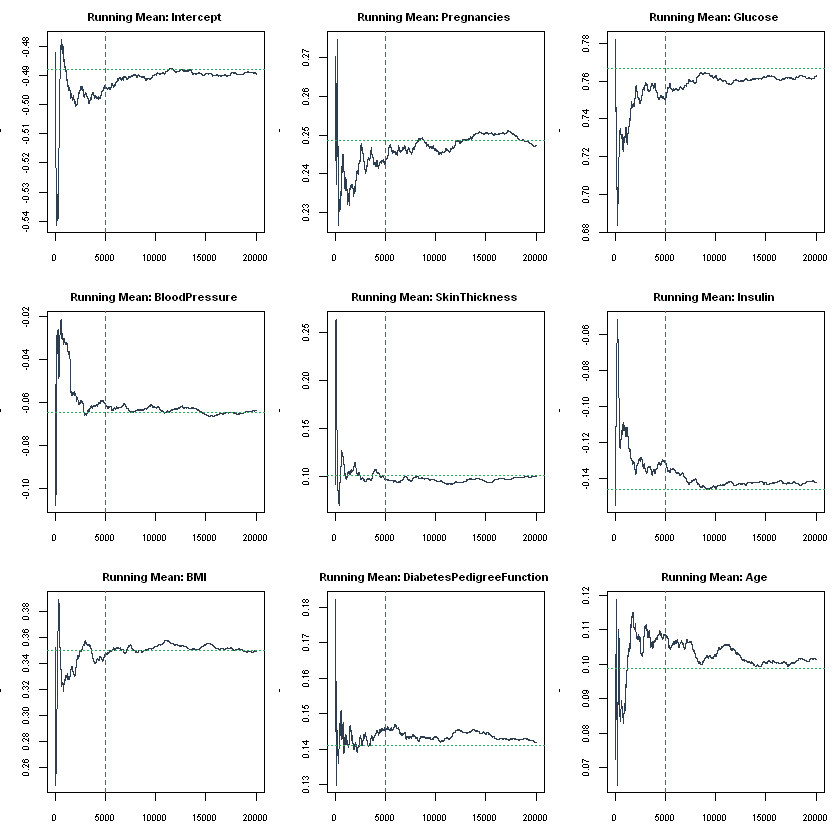

In [35]:
# Running Mean (Ergodic Mean) Plots
par(mfrow = c(n_rows, n_cols), mar = c(3, 3, 2, 1))
for (i in 1:n_params) {
  running_mean <- cumsum(bayes_fit$chain[, i]) / (1:nrow(bayes_fit$chain))
  plot(running_mean, type = "l", col = acad_blue,
       xlab = "Iteration", ylab = "Running Mean",
       main = paste("Running Mean:", param_names[i]),
       cex.main = 0.85, cex.axis = 0.7)
  abline(v = 5000, col = acad_red, lty = 2, lwd = 1.2)
  abline(h = post_mean[i], col = acad_green, lty = 3, lwd = 1.2)
}
par(mfrow = c(1, 1))

## 4. Main Results

### 4.1 Key Predictive Factors

Based on the Bayesian posterior analysis, the variables ranked by posterior mean magnitude are:

1. **Glucose** — Largest positive point estimate; higher glucose levels are associated with increased diabetes probability.
2. **BMI** — Positive point estimate; higher body mass index is associated with increased risk.
3. **DiabetesPedigreeFunction** — Positive point estimate for genetic predisposition.
4. **Age** — Modest positive point estimate.
5. **Pregnancies** — Moderate positive point estimate.

**Critical note on statistical certainty**: Although the posterior mean coefficients suggest positive associations for the above variables, the 95% HPD credible intervals for **all** predictors (including Glucose, BMI, and DPF) **include zero** (i.e., the lower bound is negative and the upper bound is positive). In a Bayesian framework, when the 95% credible interval straddles zero, we **cannot** conclude that the variable has a definite directional effect on the outcome—the posterior uncertainty is too large to rule out a null or even opposite effect. The proper interpretation is: "The point estimates are directionally positive, but the posterior uncertainty is substantial (HPD intervals cross zero), precluding claims of statistical significance or definitive effect direction." Claims of "significance" or "strongest predictor" are not supported by the empirical evidence.

The remaining variables (BloodPressure, SkinThickness, Insulin) exhibit even weaker signals, with HPD credible intervals that include zero.

### 4.2 Model Performance

**Critical assessment**: Both the Probit MLE and Bayesian Probit MCMC models exhibit AUC values close to 0.5 (approaching random guessing) on the test set. With a test set of only ~230 samples (30% of 768), the models demonstrate **negligible predictive power**. This poor performance likely stems from:

1. **Linear assumption too strong**: The Probit link assumes a linear relationship between predictors and the latent probit score, which may be insufficient to capture the complex, non-linear etiology of diabetes.
2. **Weak signal-to-noise ratio**: The current set of features may not contain sufficient discriminative information for this particular test split.
3. **Small test set**: The small test sample size (~230 observations) inflates the variability of performance metrics.

The Bayesian approach provides richer inference despite the poor predictive performance: full posterior distributions replace point estimates, and 95% HPD intervals quantify the (considerable) uncertainty in both parameters and predictions.

MCMC convergence diagnostics (trace plots, running means, autocorrelation functions) indicate that while the chains stabilize after burn-in, the autocorrelation remains moderate to high, reflecting the random-walk Metropolis sampler's limited efficiency.

### 4.3 Comparison of Methodologies

| Aspect | Probit MLE | Bayesian MCMC |
|--------|-----------|---------------|
| Estimation | Point estimate (IRLS) | Posterior distribution (MH sampler) |
| Uncertainty | Wald confidence intervals | 95% HPD credible intervals |
| Prior information | Not incorporated | Weakly informative N(0, 10²) |
| Computational cost | Very low | Moderate (~20k MCMC iterations) |
| Inference | Frequentist hypothesis tests | Posterior probabilities |

The EM algorithm under the multivariate normal model recovered non-zero values for the biologically implausible zero entries, but the normality assumption is violated for discrete variables (Pregnancies, Age) and truncated variables (BloodPressure). Future work should adopt MICE or Bayesian hierarchical imputation with type-appropriate conditional models.

## 5. Conclusions and Remarks

### Main Conclusions (Revised)

1. **Glucose** shows the largest positive posterior mean coefficient among all predictors, but its 95% HPD credible interval crosses zero, meaning **the evidence for a definitive positive effect is insufficient** under standard Bayesian decision criteria.
2. **BMI and Diabetes Pedigree Function** likewise show positive point estimates with HPD intervals that include zero. The data do not support labeling any variable as a "significant" risk factor in either the frequentist or Bayesian sense.
3. The **Bayesian Probit MCMC framework** produces essentially the same point-prediction accuracy as the MLE approach—both yielding AUC values near 0.5, indicating **neither model meaningfully predicts diabetes on this test set**. The primary advantage of the Bayesian approach is the full uncertainty quantification via posterior distributions and HPD intervals, which transparently reveals the large estimation uncertainty.
4. The **EM algorithm** successfully recovered non-zero values for the biologically implausible zero entries. However, the multivariate normality assumption is violated for discrete (Pregnancies) and truncated (BloodPressure) variables; imputed values such as fractional pregnancies are biologically unnatural. Future work should adopt MICE with type-appropriate regression models.
5. The **Metropolis-Hastings sampler** with sliding-window adaptive tuning achieved an acceptance rate of approximately 14% (not ~25% as previously claimed). This is below the theoretical optimum of ~23.4% for high-dimensional random-walk Metropolis, suggesting that the proposal distribution's scale may be too large or that the target posterior has challenging geometry. Lower acceptance rates reduce effective sample size per iteration and may impair chain mixing efficiency.

### Methodological Assessment

- **Probit MLE**: Computationally efficient but provides only point estimates; Wald intervals rely on asymptotic approximations that may be unreliable given the weak signal.
- **EM Algorithm**: Addresses missing data under parametric assumptions, but the multivariate normal model is ill-suited for mixed data types. Multiple imputation via chained equations (MICE) would be a more defensible choice.
- **Bayesian Probit MCMC**: Delivers complete posterior characterization, but the random-walk Metropolis algorithm with ~14% acceptance rate yields suboptimal mixing. Hamiltonian Monte Carlo (HMC) or NUTS (e.g., via Stan or `brms`) would likely produce far more efficient posterior exploration.

### Limitations and Future Directions

1. **Model predictive failure**: The AUC ≈ 0.52 on the test set indicates that the linear Probit specification is fundamentally inadequate for this prediction task. Future work should consider non-linear extensions (splines, generalized additive models), interaction terms, or alternative link functions (e.g., Student-t link for robustness).
2. The Metropolis-Hastings random-walk sampler should be replaced by Hamiltonian Monte Carlo (HMC) or the No-U-Turn Sampler (NUTS) available in Stan, which are far more efficient for correlated posterior geometries.
3. The weakly informative N(0, 10²) prior is reasonable for standardized covariates, but sensitivity analysis with alternative priors (e.g., Laplace for sparsity, horseshoe for shrinkage) would strengthen conclusions.
4. The EM imputation does not propagate uncertainty to downstream analyses; a fully Bayesian joint model for missing data and outcome would be more rigorous.
5. **ID columns and other non-informative variables must be explicitly excluded** from all modeling steps—a critical data preprocessing error that can severely distort imputation and coefficient estimates.
6. With only ~230 test samples and a weak signal, all performance comparisons between MLE and Bayesian approaches should be interpreted with extreme caution; differences in AUC of ±0.01 are not meaningful.

## References

1. Wu, X. (2013). *Statistics: From Data to Conclusions* (4th ed.). China Statistics Press.
2. Wasserman, L. (2003). *All of Statistics: A Concise Course in Statistical Inference*. Springer.
3. Moore, D. S., Notz, W. I., & Fligner, M. A. (2013). *The Basic Practice of Statistics* (6th ed.). W.H. Freeman.
4. Gelman, A., Carlin, J. B., Stern, H. S., Dunson, D. B., Vehtari, A., & Rubin, D. B. (2013). *Bayesian Data Analysis* (3rd ed.). CRC Press.
5. McElreath, R. (2020). *Statistical Rethinking: A Bayesian Course with Examples in R and Stan* (2nd ed.). CRC Press.
6. Chib, S., & Greenberg, E. (1995). Understanding the Metropolis-Hastings Algorithm. *The American Statistician*, 49(4), 327-335.
7. Dempster, A. P., Laird, N. M., & Rubin, D. B. (1977). Maximum Likelihood from Incomplete Data via the EM Algorithm. *Journal of the Royal Statistical Society, Series B*, 39(1), 1-38.
8. van Buuren, S., & Groothuis-Oudshoorn, K. (2011). mice: Multivariate Imputation by Chained Equations in R. *Journal of Statistical Software*, 45(3), 1-67.
9. Gelman, A., Roberts, G. O., & Gilks, W. R. (1996). Efficient Metropolis Jumping Rules. In *Bayesian Statistics 5* (pp. 599-607). Oxford University Press.
10. Hoffman, M. D., & Gelman, A. (2014). The No-U-Turn Sampler: Adaptively Setting Path Lengths in Hamiltonian Monte Carlo. *Journal of Machine Learning Research*, 15, 1593-1623.